In [74]:
import numpy as np
import pandas as pd


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder , MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.tree import DecisionTreeClassifier


In [76]:
df = pd.read_csv("train.csv")

In [77]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Let's Plan our Pipeline
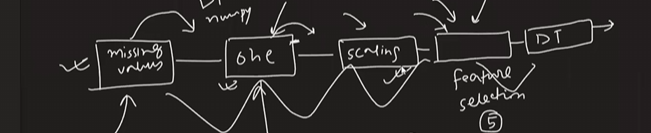

In [78]:
df.drop(columns = ['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace = True)

## Step 1: Train Test Split

In [79]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns = ['Survived']),
                                                    df['Survived'],
                                                    test_size = 0.2,
                                                    random_state = 42)

In [80]:
X_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
331,1,male,45.5,0,0,28.5000,S
733,2,male,23.0,0,0,13.0000,S
382,3,male,32.0,0,0,7.9250,S
704,3,male,26.0,1,0,7.8542,S
813,3,female,6.0,4,2,31.2750,S


In [81]:
y_train.sample(5)

601    0
795    0
503    0
544    0
242    0
Name: Survived, dtype: int64

## Imputation Transformer


In [82]:
trf1 = ColumnTransformer([
    ('impute_age',SimpleImputer(),[2]),
    ('imputer_embarked',SimpleImputer(strategy = "most_frequent"),[6])],
                         remainder = 'passthrough')


## 'impute_age'--> label for identification
##SimpleImputer() --> Transformer--> By Default Mean
##  [2]  ---> column at index 2

## OneHotEncoder


In [83]:
trf2 = ColumnTransformer([
    ('ohe_sex_embarked', OneHotEncoder(sparse_output = False , handle_unknown = 'ignore'),[1,6])
],
                         remainder = 'passthrough')

# no. of columns before OHE = > 7
# No. Of Columns after OHE --> 5 (original)  + (2+ 3 ) ==> 10

## Scaling
- here we doing scaling for all the colmns
- When we doing Feature scaling Most of time we have to use MinMaxScaling

In [84]:
trf3 = ColumnTransformer([
    ('scale',MinMaxScaler(),slice(0,10))   # we havr to take all 10 colms after OHE
])


# Slice  ---> it will apply this transformation through out the Range

# Feature Selection


In [85]:
trf4 = SelectKBest(score_func = chi2, k = 8)

# Taking Top 8 Columns Only

# Train The Model
- using Decision Tree

In [86]:
trf5 = DecisionTreeClassifier()

### Till Now we created all the blocks , Now we have to Connect them Using Pipeline




# Create Pipeline

In [87]:
pipe = Pipeline([('trf1',trf1),
             ('trf2',trf2),
             ('trf3',trf3), 
             ('trf4',trf4),
             ('trf5',trf5)
            ])

# Pipeline vs make_pipeline

pipeline requires naming of steps, make_pipline does not .

( same Logic apply for ColumnTransformer vs make_column_transformer)

In [88]:
# Alternate Syntax

pipe = make_pipeline(trf1, trf2, trf3 , trf4, trf5)

In [89]:
#Train 


pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer-1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('impute_age', SimpleImputer(),
                                                  [2]),
                                                 ('imputer_embarked',
                                                  SimpleImputer(strategy='most_frequent'),
                                                  [6])])),
                ('columntransformer-2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ohe_sex_embarked',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  [1, 6])])),
                ('columntransformer-3',
                 ColumnTransformer(transformers=[('scale', MinMaxScaler(),
                                                  slice(0, 10, None))])),
                ('selectkbest',
                 SelectKBest(k=8,
                             score_func=<function chi2 at 0x00000158984B51F0>)),
                ('decisiontreeclassifier', DecisionTreeClassifier())])

# Explore the Pipeline

In [90]:
# code 

pipe.named_steps.keys()
# To get names of Blocks which save by pipeline

dict_keys(['columntransformer-1', 'columntransformer-2', 'columntransformer-3', 'selectkbest', 'decisiontreeclassifier'])

In [91]:
pipe.named_steps['columntransformer-1']

# To get Inside the perticular Block

ColumnTransformer(remainder='passthrough',
                  transformers=[('impute_age', SimpleImputer(), [2]),
                                ('imputer_embarked',
                                 SimpleImputer(strategy='most_frequent'),
                                 [6])])

In [92]:

pipe.named_steps['columntransformer-1'].transformers_

[('impute_age', SimpleImputer(), [2]),
 ('imputer_embarked', SimpleImputer(strategy='most_frequent'), [6]),
 ('remainder',
  FunctionTransformer(accept_sparse=True, check_inverse=False,
                      feature_names_out='one-to-one'),
  [0, 1, 3, 4, 5])]

In [93]:
# 1st element in Block

pipe.named_steps['columntransformer-1'].transformers_[0]

('impute_age', SimpleImputer(), [2])

In [94]:

pipe.named_steps['columntransformer-1'].transformers_[0][1].statistics_

# what is the value of Mean

array([29.49884615])

In [95]:

pipe.named_steps['columntransformer-1'].transformers_[1][1].statistics_

# what is the Most freq. val

array(['S'], dtype=object)

In [96]:
# To Display Pipeline

from sklearn import set_config
set_config(display='diagram')

# if bychance it not shown Diagram


In [97]:
pipe.named_steps['selectkbest']


SelectKBest(k=8, score_func=<function chi2 at 0x00000158984B51F0>)

In [98]:
# Predict 
y_pred = pipe.predict(X_test)

In [99]:
y_pred

array([1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       0, 0, 0])

In [100]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.6256983240223464

# Cross Validation Using Pipeline




In [101]:
# cross validation using cross_val_score

from sklearn.model_selection import cross_val_score
cross_val_score(pipe, X_train, y_train , cv = 5, scoring = 'accuracy').mean()

np.float64(0.6391214419383433)

# GridSearch using Pipeline

In [104]:
pipe.get_params().keys()

dict_keys(['memory', 'steps', 'transform_input', 'verbose', 'columntransformer-1', 'columntransformer-2', 'columntransformer-3', 'selectkbest', 'decisiontreeclassifier', 'columntransformer-1__force_int_remainder_cols', 'columntransformer-1__n_jobs', 'columntransformer-1__remainder', 'columntransformer-1__sparse_threshold', 'columntransformer-1__transformer_weights', 'columntransformer-1__transformers', 'columntransformer-1__verbose', 'columntransformer-1__verbose_feature_names_out', 'columntransformer-1__impute_age', 'columntransformer-1__imputer_embarked', 'columntransformer-1__impute_age__add_indicator', 'columntransformer-1__impute_age__copy', 'columntransformer-1__impute_age__fill_value', 'columntransformer-1__impute_age__keep_empty_features', 'columntransformer-1__impute_age__missing_values', 'columntransformer-1__impute_age__strategy', 'columntransformer-1__imputer_embarked__add_indicator', 'columntransformer-1__imputer_embarked__copy', 'columntransformer-1__imputer_embarked__fil

In [107]:
# gridsearchcv

params = { 
    'trf5__max_depth':[1,2,3,4,5,None]

}

In [109]:
# The key must be: stepname + __ + parametername
params = { 
    'decisiontreeclassifier__max_depth': [1, 2, 3, 4, 5, None]
}

# Now run the grid search
grid = GridSearchCV(pipe, params, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer-1',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('impute_age',
                                                                         SimpleImputer(),
                                                                         [2]),
                                                                        ('imputer_embarked',
                                                                         SimpleImputer(strategy='most_frequent'),
                                                                         [6])])),
                                       ('columntransformer-2',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe_sex_embarked',
                                                                         OneHotEncoder(handle_unkn...,
                                                                                       sparse_output=False),
                                                                         [1,
                                                                          6])])),
                                       ('columntransformer-3',
                                        ColumnTransformer(transformers=[('scale',
                                                                         MinMaxScaler(),
                                                                         slice(0, 10, None))])),
                                       ('selectkbest',
                                        SelectKBest(k=8,
                                                    score_func=<function chi2 at 0x00000158984B51F0>)),
                                       ('decisiontreeclassifier',
                                        DecisionTreeClassifier())]),
             param_grid={'decisiontreeclassifier__max_depth': [1, 2, 3, 4, 5,
                                                               None]},
             scoring='accuracy')

In [110]:
grid.best_score_

np.float64(0.6391214419383433)

In [111]:
grid.best_params_

{'decisiontreeclassifier__max_depth': 2}

# Exporting the Pipeline

In [112]:
# export

import pickle
pickle.dump(pipe, open('pipe.pkl','wb'))